# Rich Display in xeus-lfortran

xeus-lfortran supports Jupyter's rich MIME display system via the `lfortran_display` module,
injected automatically at kernel startup — the same pattern as xeus-swift's
`MimeBundleRepresentable` / `kDisplaySetupCode` bootstrap.

| Subroutine | MIME type | Use for |
|---|---|---|
| `display_html(html)` | `text/html` | Styled text, tables, widgets |
| `display_svg(svg)` | `image/svg+xml` | Vector graphics, charts |
| `display_latex(s)` | `text/latex` | Math (rendered by MathJax) |
| `display_markdown(s)` | `text/markdown` | Formatted prose |
| `display_image(w, h, rgba)` | `image/bmp` | Pixel images from arrays |

All subroutines call `lfortran_display_data` (C bridge defined in the kernel binary),
which calls `xeus::get_interpreter().display_data(...)` — the same call xeus-cpp uses
inside `xcpp::display()`.

## 1 — HTML

In [1]:
use lfortran_display, only: display_html
call display_html( &
    '<div style="font-family:sans-serif;padding:16px;border-left:4px solid #0066cc">' // &
    '<h2 style="color:#0066cc">Hello from xeus-lfortran!</h2>' // &
    '<p>This paragraph is rendered as <strong>HTML</strong> inside JupyterLab.</p>' // &
    '</div>')

Hello from xeus-lfortran! This paragraph is rendered as HTML inside JupyterLab.

## 2 — HTML table

In [2]:
use lfortran_display, only: display_html
call display_html( &
    '<table style="border-collapse:collapse;font-family:sans-serif">' // &
    '<thead><tr style="background:#333;color:#fff">' // &
    '<th style="padding:8px 16px">i</th>' // &
    '<th style="padding:8px 16px">i²</th>' // &
    '<th style="padding:8px 16px">i³</th>' // &
    '</tr></thead><tbody>' // &
    '<tr><td style="padding:6px 16px">1</td><td>1</td><td>1</td></tr>' // &
    '<tr style="background:#f9f9f9"><td style="padding:6px 16px">2</td><td>4</td><td>8</td></tr>' // &
    '<tr><td style="padding:6px 16px">3</td><td>9</td><td>27</td></tr>' // &
    '<tr style="background:#f9f9f9"><td style="padding:6px 16px">4</td><td>16</td><td>64</td></tr>' // &
    '<tr><td style="padding:6px 16px">5</td><td>25</td><td>125</td></tr>' // &
    '</tbody></table>')

i,i²,i³
1,1,1
2,4,8
3,9,27
4,16,64
5,25,125


## 3 — LaTeX (MathJax)

In [3]:
use lfortran_display, only: display_latex
call display_latex('$$\int_{-\infty}^{\infty} e^{-x^2}\,dx = \sqrt{\pi}$$')

## 4 — SVG (inline vector graphic)

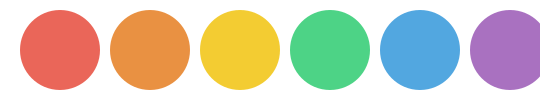

In [4]:
use lfortran_display, only: display_svg
call display_svg( &
    "<svg xmlns='http://www.w3.org/2000/svg' width='540' height='100'>" // &
    "<circle cx='60'  cy='50' r='40' fill='#e74c3c' opacity='0.85'/>" // &
    "<circle cx='150' cy='50' r='40' fill='#e67e22' opacity='0.85'/>" // &
    "<circle cx='240' cy='50' r='40' fill='#f1c40f' opacity='0.85'/>" // &
    "<circle cx='330' cy='50' r='40' fill='#2ecc71' opacity='0.85'/>" // &
    "<circle cx='420' cy='50' r='40' fill='#3498db' opacity='0.85'/>" // &
    "<circle cx='510' cy='50' r='40' fill='#9b59b6' opacity='0.85'/>" // &
    "</svg>")

## 5 — SVG bar chart

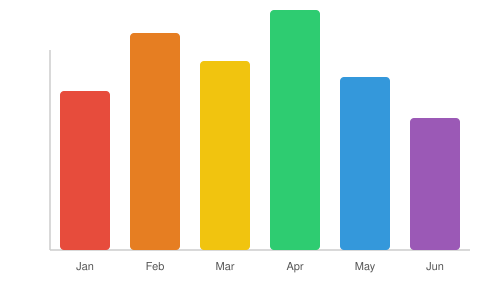

In [5]:
use lfortran_display, only: display_svg
! A simple 6-bar chart built by string concatenation.
! In a real notebook you would generate the SVG programmatically.
call display_svg( &
    "<svg xmlns='http://www.w3.org/2000/svg' width='500' height='300'" // &
    " style='background:white;font-family:Helvetica,Arial,sans-serif;'>" // &
    "<line x1='50' y1='50' x2='50' y2='250' stroke='#ccc' stroke-width='1.5'/>" // &
    "<line x1='50' y1='250' x2='470' y2='250' stroke='#ccc' stroke-width='1.5'/>" // &
    "<rect x='60'  y='91'  width='50' height='159' fill='#e74c3c' rx='4'/>" // &
    "<rect x='130' y='33'  width='50' height='217' fill='#e67e22' rx='4'/>" // &
    "<rect x='200' y='61'  width='50' height='189' fill='#f1c40f' rx='4'/>" // &
    "<rect x='270' y='10'  width='50' height='240' fill='#2ecc71' rx='4'/>" // &
    "<rect x='340' y='77'  width='50' height='173' fill='#3498db' rx='4'/>" // &
    "<rect x='410' y='118' width='50' height='132' fill='#9b59b6' rx='4'/>" // &
    "<text x='85'  y='270' text-anchor='middle' font-size='11' fill='#555'>Jan</text>" // &
    "<text x='155' y='270' text-anchor='middle' font-size='11' fill='#555'>Feb</text>" // &
    "<text x='225' y='270' text-anchor='middle' font-size='11' fill='#555'>Mar</text>" // &
    "<text x='295' y='270' text-anchor='middle' font-size='11' fill='#555'>Apr</text>" // &
    "<text x='365' y='270' text-anchor='middle' font-size='11' fill='#555'>May</text>" // &
    "<text x='435' y='270' text-anchor='middle' font-size='11' fill='#555'>Jun</text>" // &
    "</svg>")

## 6 — Pixel image from array

`display_image(w, h, rgba)` takes a Fortran array `rgba(4, w, h)` with integer RGBA channels
and renders it as a BMP.  This is the same mechanism used by the Mandelbrot notebook.
Here we render a 256×256 HSV colour wheel.

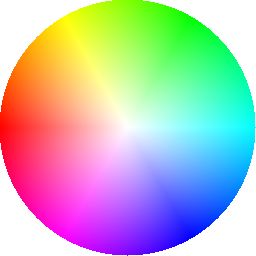

In [6]:
use lfortran_display, only: display_image
integer, parameter :: W = 256, H = 256
integer :: pixels(4, W, H), ci, cj
real :: cx, cy, dist, angle, hue, r, g, b, sat, val, f, p, q, t
integer :: hi

do cj = 1, H
    do ci = 1, W
        cx = (ci - W/2.0) / (W/2.0)
        cy = (cj - H/2.0) / (H/2.0)
        dist = sqrt(cx**2 + cy**2)
        if (dist > 1.0) then
            pixels(1,ci,cj) = 255
            pixels(2,ci,cj) = 255
            pixels(3,ci,cj) = 255
            pixels(4,ci,cj) = 255
        else
            hue = atan2(cy, cx) / (2.0 * 3.14159265) + 0.5
            sat = dist; val = 1.0
            hi  = int(hue * 6)
            f   = hue * 6 - hi
            p   = val * (1 - sat)
            q   = val * (1 - f * sat)
            t   = val * (1 - (1-f) * sat)
            if     (mod(hi,6) == 0) then; r=val; g=t;   b=p
            else if(mod(hi,6) == 1) then; r=q;   g=val; b=p
            else if(mod(hi,6) == 2) then; r=p;   g=val; b=t
            else if(mod(hi,6) == 3) then; r=p;   g=q;   b=val
            else if(mod(hi,6) == 4) then; r=t;   g=p;   b=val
            else;                         r=val; g=p;   b=q
            end if
            pixels(1,ci,cj) = int(r * 255)
            pixels(2,ci,cj) = int(g * 255)
            pixels(3,ci,cj) = int(b * 255)
            pixels(4,ci,cj) = 255
        end if
    end do
end do
call display_image(W, H, pixels)

## 7 — User-defined type with mime_bundle_repr

Ondrej's design: a user defines a derived type and a `display` subroutine for it.
The kernel primitive (`lf_display_data`) is the low-level building block — users
build rich display for their own types on top of it, just as xeus-cpp users
specialise `mime_bundle_repr<T>()` via ADL.

In [ ]:
! Define a simple coloured-box type and its display subroutine.
module color_swatch_mod
  use lfortran_display, only: display_html
  implicit none

  type :: color_swatch
    character(len=32) :: name
    character(len=7)  :: hex   ! e.g. "#FF6B6B"
  end type

contains

  ! mime_bundle_repr for color_swatch: renders an HTML coloured box.
  ! The kernel does not need to know about this type — the user calls
  ! display(swatch) explicitly, which is the recommended pattern.
  subroutine display(swatch)
    type(color_swatch), intent(in) :: swatch
    call display_html( &
        '<div style="display:inline-flex;align-items:center;gap:12px;' // &
        'font-family:sans-serif;font-size:16px;">' // &
        '<div style="width:60px;height:60px;background:' // trim(swatch%hex) // &
        ';border-radius:6px;border:1px solid #ccc;"></div>' // &
        '<span><strong>' // trim(swatch%name) // '</strong> &nbsp; ' // &
        trim(swatch%hex) // '</span></div>')
  end subroutine
end module color_swatch_mod

In [ ]:
use color_swatch_mod
type(color_swatch) :: sw
sw%name = "Fortran Blue"
sw%hex  = "#4472C4"
call display(sw)